In [1]:
import re
import json
from PIL import Image
from pathlib import Path
from copy import deepcopy

import torch
import pymupdf
import numpy as np
from scipy.spatial import cKDTree
from openpyxl import load_workbook
from transformers import (
    AutoProcessor,
    AutoModelForImageTextToText,
    AutoImageProcessor, 
    AutoModelForObjectDetection
)
from deep_translator import GoogleTranslator

/home/aleksandr/Рабочий стол/ai-catalog-parser/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CATALOG_PATH = "../data/catalogs/2026箭牌卫浴产品-5-9.pdf"

START_PAGE = 1
PAGES_CNT = 3

In [3]:
def get_image(page, dpi=200):
    zoom = dpi / 72
    matrix = pymupdf.Matrix(zoom, zoom)

    pixmap = page.get_pixmap(
        matrix=matrix,
        alpha=False,
    )

    mode = "RGBA" if pixmap.alpha else "RGB"
    img = Image.frombytes(mode, [pixmap.width, pixmap.height], pixmap.samples)

    return img

In [4]:
catalog = pymupdf.open(CATALOG_PATH)

pages = [
    get_image(page) for page_id, page in enumerate(catalog) 
    if page_id >= START_PAGE and page_id < PAGES_CNT + START_PAGE
]

MuPDF error: format error: cannot find object in xref (4714 0 R)

MuPDF error: format error: cannot find object in xref (4714 0 R)



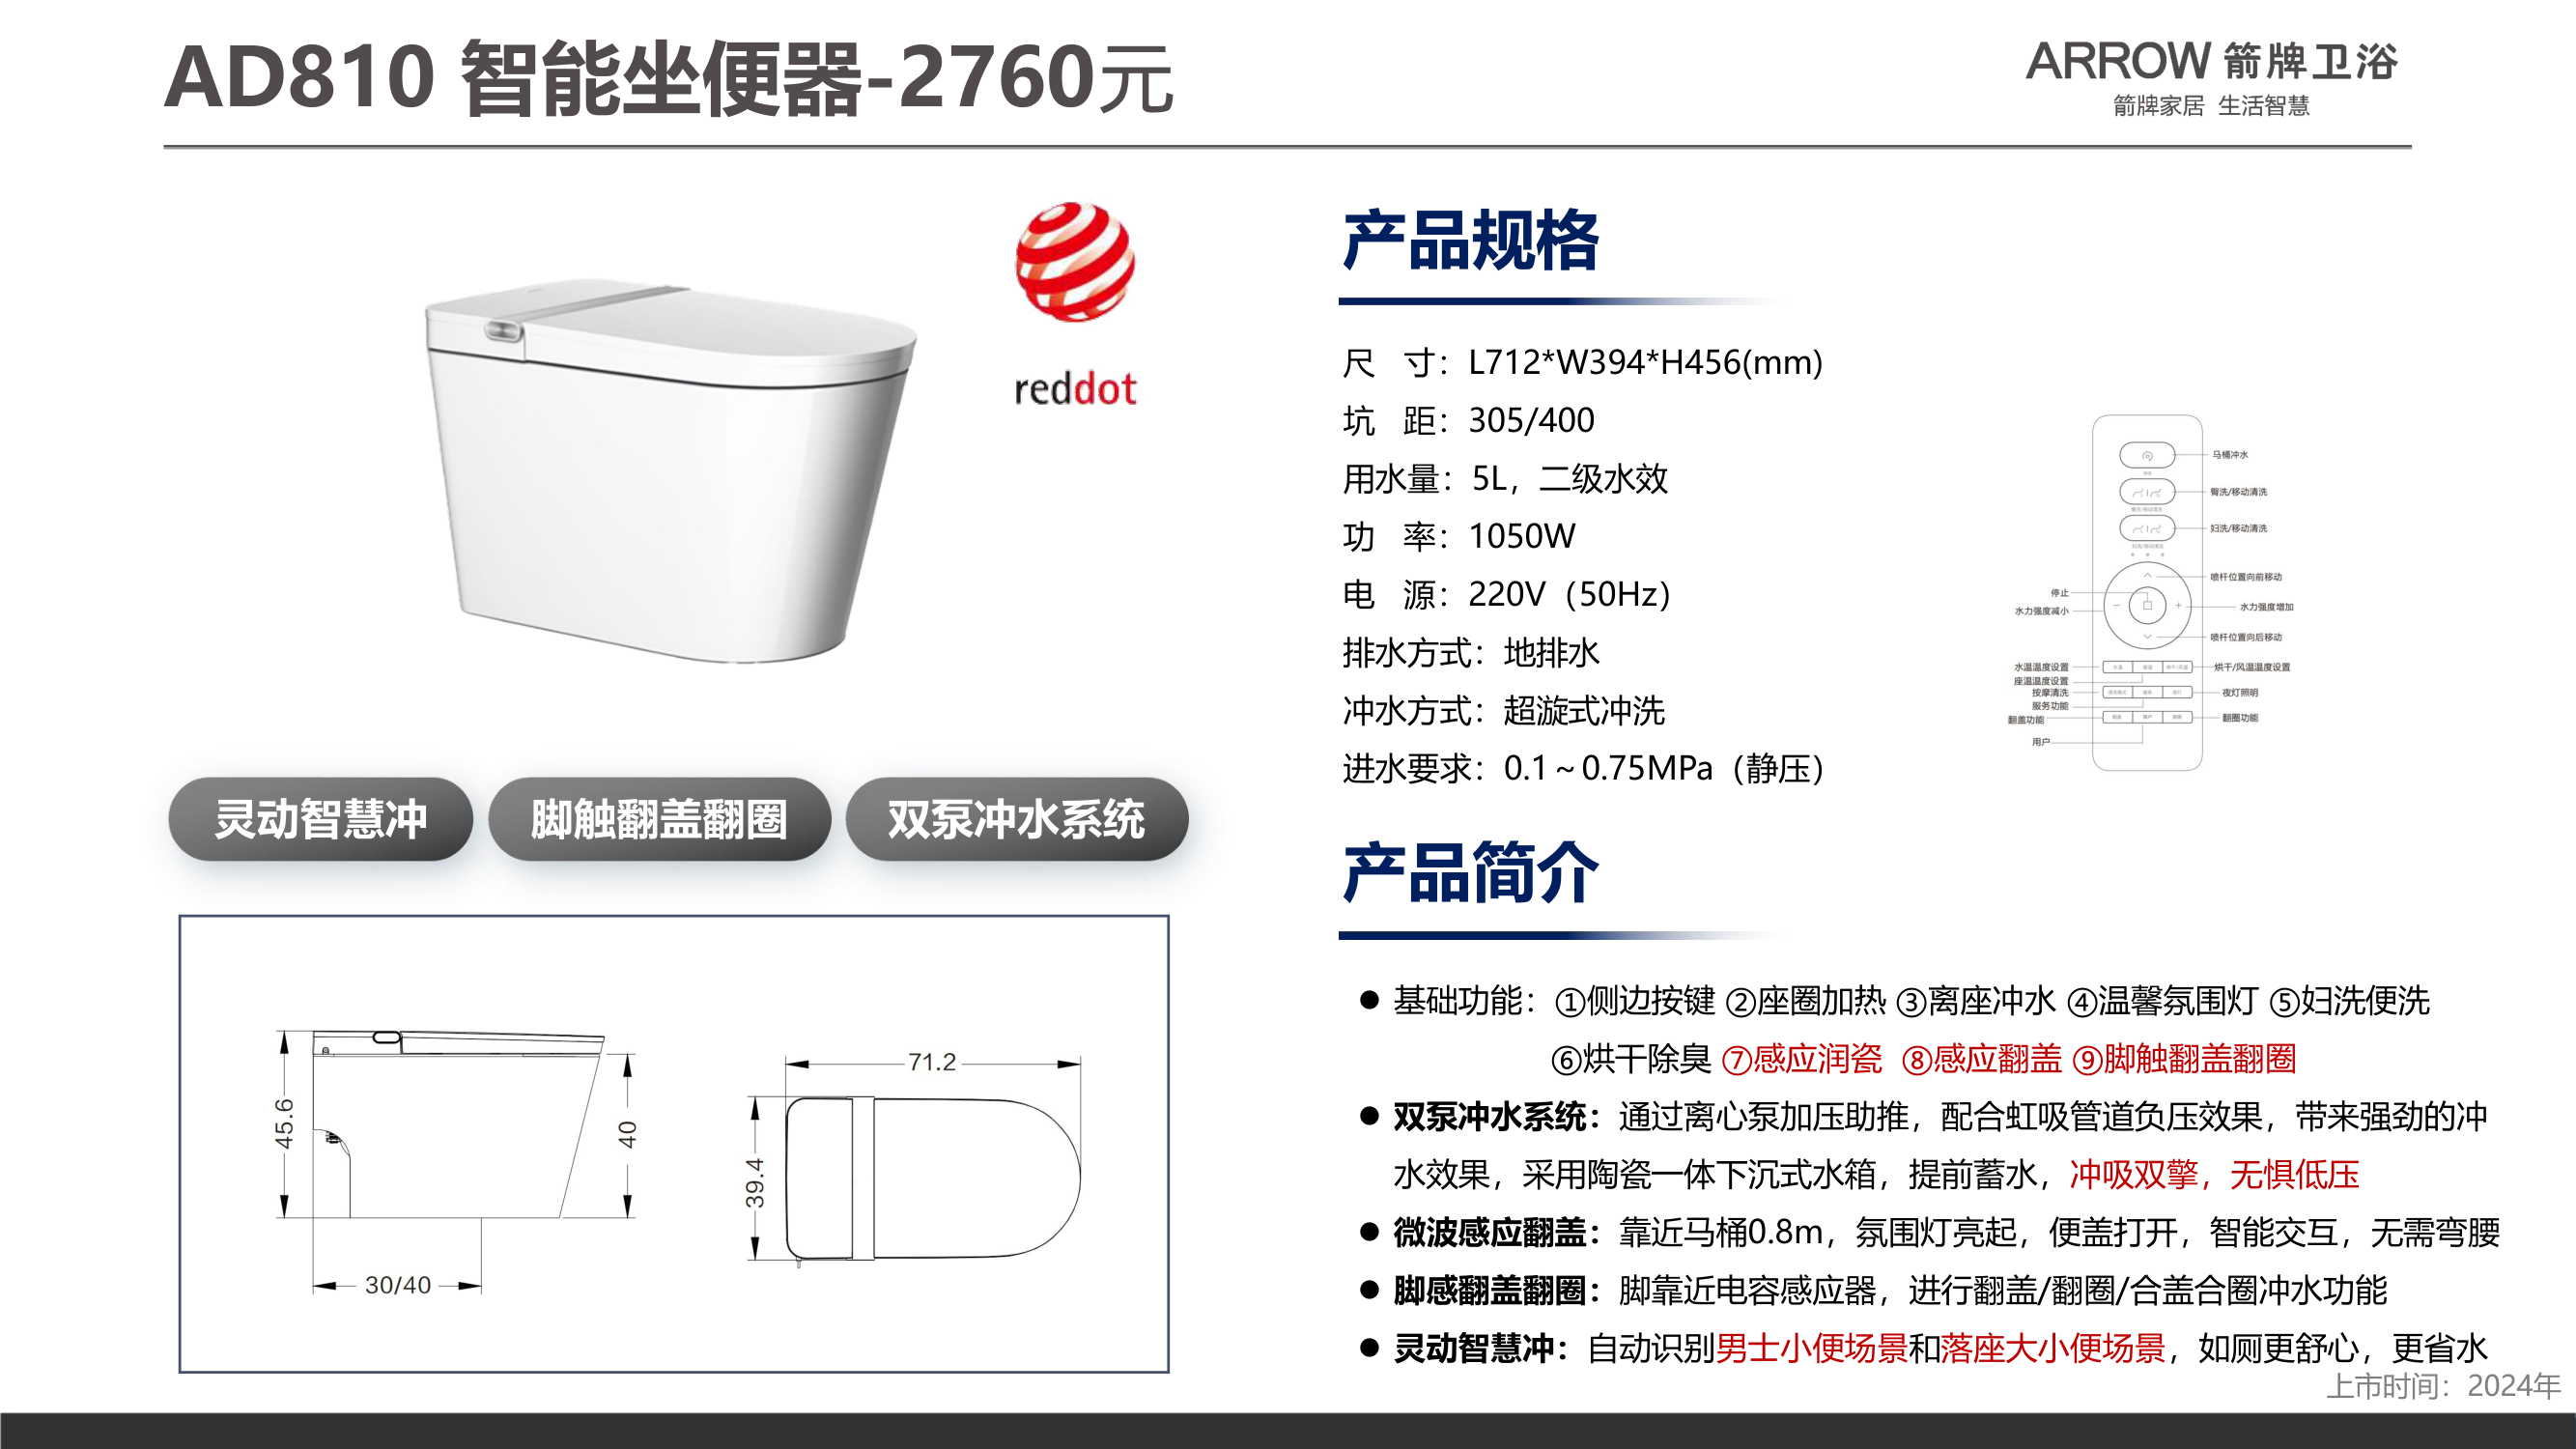

In [5]:
pages[1]

In [6]:
vlm = AutoModelForImageTextToText.from_pretrained(
    "numind/NuExtract3",
    dtype=torch.bfloat16,
    device_map="auto",
).eval()
vlm_processor = AutoProcessor.from_pretrained(
    "numind/NuExtract3"
)

detector = AutoModelForObjectDetection.from_pretrained(
    "PaddlePaddle/PP-DocLayoutV3_safetensors", 
    device_map="auto"
).eval()
detector_processor = AutoImageProcessor.from_pretrained(
    "PaddlePaddle/PP-DocLayoutV3_safetensors"
)

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 858/858 [00:00<00:00, 13847.01it/s]


In [7]:
translator = GoogleTranslator(target="ru")

In [8]:
def run_vlm(images: list[Image], **chat_template_kwargs):
    
    enable_thinking = chat_template_kwargs.pop("enable_thinking", False)
    
    template = [
        {
            "name": "verbatim-string",
            "description": ["verbatim-string"],
            "brand": "verbatim-string",
            "product_center": {
                "x": "number",
                "y": "number",
            },
            "price": {
                "value": "number",
                "currency": "currency",
            },
            "specifications": {
                "length": {
                    "value": "number",
                    "unit": "string"
                },
                "width": {
                    "value": "number",
                    "unit": "string"
                },
                "height": {
                    "value": "number",
                    "unit": "string"
                },
                "weight": {
                    "value": "number",
                    "unit": "string"
                },
                "volume": {
                    "value": "number",
                    "unit": "string"
                },
                "square": {
                    "value": "number",
                    "unit": "string"
                },
                "other": ["verbatim-string"],
            },
            "sku": "verbatim-string",
        },
    ]

    prompt = f"""
    Extract ONLY real product cards from the catalog page.

    A valid product card MUST contain:
    - product name/title
    - price
    - technical specifications

    Return ONLY valid JSON matching the schema.

    Each product_center MUST satisfy:
    - normalized coordinates in range [0.0, 1.0]
    - x and y represent the center of the main product photo ONLY
    - coordinates are relative to full page width and height
    - (0,0) is top-left, (1,1) is bottom-right
    - values MUST NOT exceed [0,1] under any circumstance

    If the page does not contain ANY valid product cards,
    return exactly: []
    """

    messages = [
        [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": image,
                    },
                    {
                        "type": "text",
                        "text": f"{prompt}",
                    },
                ],
            }
        ]
        for image in images
    ]

    inputs = vlm_processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        enable_thinking=enable_thinking,
        template=json.dumps(template, indent=4),
        padding=True,
        **chat_template_kwargs,
    ).to(vlm.device)

    with torch.inference_mode():
        generated_ids = vlm.generate(
            **inputs, 
            max_new_tokens=4096,
            do_sample=False,
        )
        
    generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]

    outputs = vlm_processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )

    if enable_thinking:
        outputs = [
            re.sub(
                r'.*?</think>', 
                '', 
                output, 
                flags=re.DOTALL
            )
            for output in outputs
        ]

    return [
        output.strip() for output in outputs
    ]

In [9]:
vlm_results = run_vlm(pages)
vlm_results = [json.loads(res) for res in vlm_results]

print(json.dumps(vlm_results, indent=4, ensure_ascii=False))

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


[
    [
        {
            "name": "智能坐便器",
            "description": [
                "烘干除臭",
                "一键旋钮",
                "感应翻盖",
                "妇洗便洗",
                "低水压冲水",
                "紫外线除菌",
                "脚触冲水",
                "座圈加热",
                "离座冲水"
            ],
            "brand": "ARROW 箭牌卫浴",
            "product_center": {
                "x": 0.75,
                "y": 0.5
            },
            "price": {
                "value": null,
                "currency": null
            },
            "specifications": {
                "length": {
                    "value": null,
                    "unit": null
                },
                "width": {
                    "value": null,
                    "unit": null
                },
                "height": {
                    "value": null,
                    "unit": null
                },
                "weight": {
                    "value": null,
                 

In [10]:
TRANSLATABLE_FIELDS = {
    "name",
    "description",
    "brand",
    "other",
    "unit"
}

In [11]:
def collect_translatable_texts(obj, field_name=None, collected=None):

    if collected is None:
        collected = []

    if isinstance(obj, dict):
        for key, value in obj.items():
            collect_translatable_texts(
                value,
                field_name=key,
                collected=collected
            )

    elif isinstance(obj, list):
        if field_name in TRANSLATABLE_FIELDS:
            for item in obj:
                if isinstance(item, str):
                    collected.append(item)
        else:
            for item in obj:
                collect_translatable_texts(
                    item,
                    field_name=field_name,
                    collected=collected
                )

    elif isinstance(obj, str):
        if field_name in TRANSLATABLE_FIELDS:
            collected.append(obj)

    return collected


def apply_translations(
    obj,
    translations,
    index,
    field_name=None
):
    if isinstance(obj, dict):
        result = {}

        for key, value in obj.items():
            result[key] = apply_translations(
                value,
                translations,
                index,
                field_name=key
            )

        return result

    elif isinstance(obj, list):
        if field_name in TRANSLATABLE_FIELDS:
            result = []

            for item in obj:
                if isinstance(item, str):
                    result.append(translations[index[0]])
                    index[0] += 1
                else:
                    result.append(item)

            return result

        return [
            apply_translations(
                item,
                translations,
                index,
                field_name=field_name
            )
            for item in obj
        ]

    elif isinstance(obj, str):
        if field_name in TRANSLATABLE_FIELDS:
            translated = translations[index[0]]
            index[0] += 1
            return translated

    return obj


def translate_json_objects(json_objects):


    result = deepcopy(json_objects)


    all_texts = []
    for obj in result:
        collect_translatable_texts(
            obj,
            collected=all_texts
        )

    if not all_texts:
        return result

    translations = translator.translate_batch(
        all_texts
    )

    index = [0]

    translated_result = []

    for obj in result:

        translated_obj = apply_translations(
            obj,
            translations,
            index
        )

        translated_result.append(
            translated_obj
        )

    return translated_result

In [12]:
vlm_results = translate_json_objects(vlm_results)

In [13]:
print(json.dumps(vlm_results, indent=4, ensure_ascii=False))

[
    [
        {
            "name": "Умный туалет",
            "description": [
                "Сушка и дезодорация",
                "Ручка с одной кнопкой",
                "Индукционная откидная крышка",
                "Мытье женского туалета",
                "Промывка водой под низким давлением",
                "УФ-стерилизация",
                "Прикосновение к ноге",
                "Подогрев сидений",
                "Смывать не сидя"
            ],
            "brand": "СТРЕЛКА Ванная комната Стрелка",
            "product_center": {
                "x": 0.75,
                "y": 0.5
            },
            "price": {
                "value": null,
                "currency": null
            },
            "specifications": {
                "length": {
                    "value": null,
                    "unit": null
                },
                "width": {
                    "value": null,
                    "unit": null
                },
               

In [9]:
def run_layout_detector(images: list[Image]):

    inputs = detector_processor(
        images=images, 
        return_tensors="pt"
    ).to(detector.device)

    with torch.inference_mode():
        outputs = detector(**inputs)

    detector_results = detector_processor.post_process_object_detection(
        outputs, 
        target_sizes=[img.size[::-1] for img in images]
    )

    batch_results = []
    for result in detector_results:
        boxes = result['boxes']
        label_ids = result['labels']

        images_bboxes = [
            bbox.tolist()
            for bbox, label_id in zip(boxes, label_ids)
            if detector.config.id2label[label_id.item()] == 'image'
        ]
        batch_results.append(images_bboxes)
    
    return batch_results

In [10]:
detector_results = run_layout_detector(pages)
detector_results

[[],
 [[439.56640625, 282.8601989746094, 944.6115112304688, 688.5800170898438],
  [1046.7935791015625,
   202.20286560058594,
   1180.38623046875,
   337.4819641113281],
  [274.6612854003906,
   1062.016357421875,
   667.6727294921875,
   1345.4246826171875],
  [763.9508056640625,
   1082.4696044921875,
   1125.01904296875,
   1311.5208740234375],
  [2072.7822265625, 421.0948791503906, 2378.11767578125, 805.7625732421875]],
 []]

In [19]:
def _normalize_name(name: str) -> str:
    return (
        name
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace("-", "_")
    )

def _crop_and_save(image: Image, bbox, image_path: Path):
    cropped = image.crop(bbox)
    cropped.save(image_path)

In [31]:
def calculate_products_images(pages, vlm_results, detector_results, output_dir):
    
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for page, vlm_res, det_res in zip(pages, vlm_results, detector_results):

        width, height = page.size

        products = vlm_res["products"]
        if len(products) == 0:
            continue

        if len(det_res) == 0:
            full_bbox = (0, 0, width, height)

            for product in products:

                product_name = product["name"]
                product_name = _normalize_name(product_name)

                _crop_and_save(
                    page, 
                    full_bbox, 
                    image_path=output_dir / f"{product_name}.png"
                )

            continue

        det_bboxes = np.asarray(det_res, dtype=np.float32)

        det_bbox_centers = np.column_stack([
            (det_bboxes[:, 0] + det_bboxes[:, 2]) / 2,
            (det_bboxes[:, 1] + det_bboxes[:, 3]) / 2,
        ])
        vlm_bbox_centers = np.array(
            [
                [
                    p["product_center"]["x"] * width,
                    p["product_center"]["y"] * height,
                ]
                for p in products
            ], 
            dtype=np.float32
        )

        tree = cKDTree(det_bbox_centers)
        indices = tree.query(vlm_bbox_centers, k=1)[1]

        for product, bbox_idx in zip(products, indices):

            bbox = det_bboxes[bbox_idx]

            product_name = product["name"]
            product_name = _normalize_name(product_name)

            _crop_and_save(
                page, 
                tuple(map(int, bbox)), 
                image_path=output_dir / f"{product_name}.png"
            )

In [32]:
calculate_products_images(
    pages,
    vlm_results,
    detector_results,
    output_dir = "../data/products"
)

In [35]:
COLUMN_MAPPING = {
    "name": "A",
    "sku": "D",
    
    "weight_unit": "F",
    "weight_flag": "H",
    "weight_value": "J",
    
    "length_unit": "T",
    "length_flag": "V",
    "length_value": "X",
    
    "description": "AH",
    
    "brand": "AD",
    "manufacturer": "AI",

    "image_path": "AN",
    
    "volume_unit": "AP",
    "volume_flag": "AR",
    "volume_value": "AT",

    "square_unit": "AV",
    "square_flag": "AZ",
    "square_value": "BB",

    "origin_country": "CK",
}

In [34]:
def _write_product(sheet, row: int, product: dict):

    # NAME
    sheet[f"{COLUMN_MAPPING['name']}{row}"] = product["name"]

    # SKU
    sheet[f"{COLUMN_MAPPING['sku']}{row}"] = product["sku"]

    # WEIGHT
    weight = product['specifications']["weight"]
    sheet[f"{COLUMN_MAPPING['weight_unit']}{row}"] = weight["unit"]
    sheet[f"{COLUMN_MAPPING['weight_flag']}{row}"] = bool(weight["value"])
    sheet[f"{COLUMN_MAPPING['weight_value']}{row}"] = weight["value"]

    # LENGTH
    length = product['specifications']["length"]
    sheet[f"{COLUMN_MAPPING['length_unit']}{row}"] = length["unit"]
    sheet[f"{COLUMN_MAPPING['length_flag']}{row}"] = bool(length["value"])
    sheet[f"{COLUMN_MAPPING['length_value']}{row}"] = length["value"]

    # DESCRIPTION
    description = "\n".join(product["description"])
    sheet[f"{COLUMN_MAPPING['description']}{row}"] = description

    # BRAND
    sheet[f"{COLUMN_MAPPING['brand']}{row}"] = product["brand"]

    # MANUFACTURER
    sheet[f"{COLUMN_MAPPING['manufacturer']}{row}"] = None

    # IMAGE PATH
    sheet[f"{COLUMN_MAPPING['image_path']}{row}"] = f"../data/products/{product["name"]}.png"

    # VOLUME
    volume = product['specifications']["volume"]
    sheet[f"{COLUMN_MAPPING['volume_unit']}{row}"] = volume["unit"]
    sheet[f"{COLUMN_MAPPING['volume_flag']}{row}"] = bool(volume["value"])
    sheet[f"{COLUMN_MAPPING['volume_value']}{row}"] = volume["value"]

    # SQUARE
    square = product['specifications']["square"]
    sheet[f"{COLUMN_MAPPING['square_unit']}{row}"] = square["unit"]
    sheet[f"{COLUMN_MAPPING['square_flag']}{row}"] = bool(square["value"])
    sheet[f"{COLUMN_MAPPING['square_value']}{row}"] = square["value"]

    # ORIGIN COUNTRY
    sheet[f"{COLUMN_MAPPING['origin_country']}{row}"] = None

In [38]:
workbook = load_workbook("../data/nomenclature/template.xlsx")

sheet = workbook.active
start_row = sheet.max_row + 1

for index, vlm_result in enumerate(vlm_results):
    products = vlm_result["products"]
    
    for product in products:
        row = start_row + index

        _write_product(
            sheet,
            row,
            product,
        )

workbook.save("../data/nomenclature/2026箭牌卫浴产品-5-9.xlsx")